<a href="https://colab.research.google.com/github/deorakamlesh07-droid/Celabal_CEI/blob/main/week4_kamleshdeora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: CIFAR-10 Image Classification with ANN and CNN

This notebook fulfills the complete CIFAR-10 image classification task using both an Artificial Neural Network (ANN) and a Convolutional Neural Network (CNN), then compares their performance across architectures and training strategies.


## Implementation Plan

1. Load the standard CIFAR-10 dataset with 50,000 training images and 10,000 test images.
2. Normalize pixel values from `0-255` to `0-1`.
3. Build and train a baseline ANN on flattened images using Dense and Dropout layers for 10 epochs.
4. Build and train a baseline CNN using Conv2D, BatchNormalization, MaxPooling2D, Flatten, and Dense layers for 10 epochs.
5. Plot the validation accuracy curves of ANN and CNN together on one chart.
6. Build advanced variants, including a denser ANN and an augmented CNN.
7. Train the augmented CNN for up to 20 epochs using EarlyStopping.
8. Compare final test accuracy scores across all model variants and verify every requested task.


In [2]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

keras.utils.set_random_seed(42)
np.set_printoptions(suppress=True)
print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU devices: []


In [3]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print('Training images:', x_train_full.shape)
print('Training labels:', y_train_full.shape)
print('Test images:', x_test.shape)
print('Test labels:', y_test.shape)
assert x_train_full.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


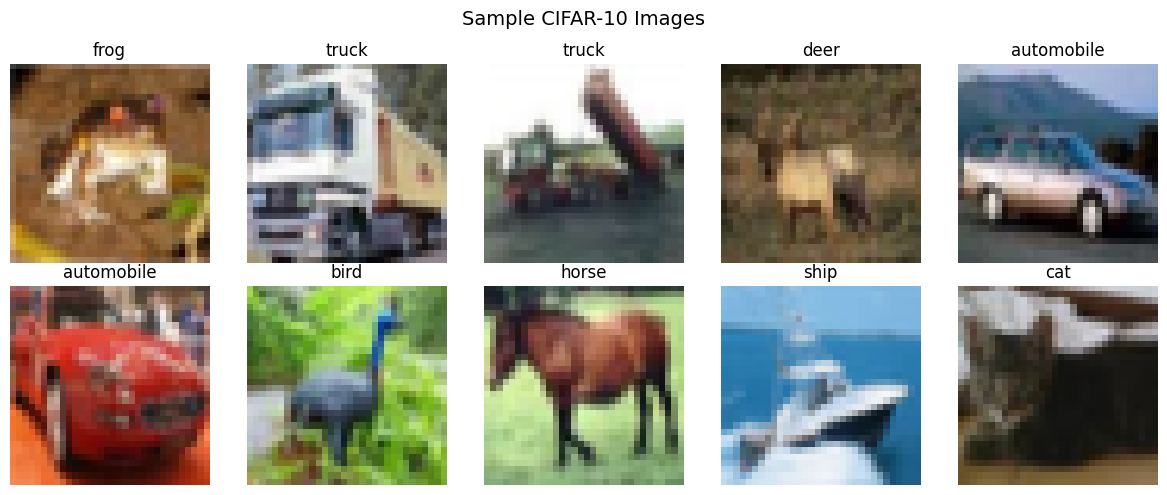

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for index, ax in enumerate(axes.flat):
    ax.imshow(x_train_full[index])
    ax.set_title(class_names[int(y_train_full[index])])
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()


In [5]:
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train_full = y_train_full.astype('int32')
y_test = y_test.astype('int32')

validation_size = 5000
x_valid = x_train_full[:validation_size]
y_valid = y_train_full[:validation_size]
x_train = x_train_full[validation_size:]
y_train = y_train_full[validation_size:]

print('Pixel range after normalization', float(x_train.min()), 'to', float(x_train.max()))
print('Train split:', x_train.shape, y_train.shape)
print('Validation split:', x_valid.shape, y_valid.shape)
print('Test split:', x_test.shape, y_test.shape)


Pixel range after normalization 0.0 to 1.0
Train split: (45000, 32, 32, 3) (45000, 1)
Validation split: (5000, 32, 32, 3) (5000, 1)
Test split: (10000, 32, 32, 3) (10000, 1)


In [6]:
batch_size = 256
baseline_epochs = 10
advanced_epochs = 20

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
valid_ds = tf.data.Dataset.from_tensor_slices((x_valid, y_valid)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10)
], name='augmentation')


In [7]:
def build_baseline_ann():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.30),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.30),
        layers.Dense(10, activation='softmax')
    ], name='baseline_ann')
    return model

def build_deeper_ann():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.35),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.35),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.35),
        layers.Dense(10, activation='softmax')
    ], name='deeper_ann')
    return model

def build_baseline_cnn():
    inputs = keras.Input(shape=(32, 32, 3))
    x=layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling2D()(x)
    x=layers.Flatten()(x)
    x=layers.Dense(128, activation='relu')(x)
    x=layers.Dropout(0.30)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='baseline_cnn')

def build_augmented_cnn():
    inputs = keras.Input(shape=(32, 32, 3))
    x = augmentation(inputs)
    for filters in [32, 64, 128]:
        x=layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x=layers.BatchNormalization()(x)
        x=layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x= layers.BatchNormalization()(x)
        x= layers.MaxPooling2D()(x)
        x =layers.Dropout(0.25)(x)

    x=layers.Flatten()(x)
    x=layers.Dense(256, activation='relu')(x)
    x =layers.Dropout(0.40)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='augmented_cnn')

def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def fit_model(model, epochs, use_early_stopping=False):
    callbacks = []
    if use_early_stopping:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            )
        )
    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=epochs,
        verbose=2,
        callbacks=callbacks
    )
    return history, callbacks

def evaluate_model(name, model, history):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    return {
        'Model': name,
        'Train Accuracy': history.history['accuracy'][-1],
        'Validation Accuracy': history.history['val_accuracy'][-1],
        'Test Accuracy': test_acc,
        'Train Loss': history.history['loss'][-1],
        'Validation Loss': history.history['val_loss'][-1],
        'Test Loss': test_loss,
        'Generalization Gap': history.history['accuracy'][-1] - history.history['val_accuracy'][-1],
        'Epochs Run': len(history.history['loss'])
    }


## 1. Baseline ANN on Flat Image Vectors

This ANN uses flattened image vectors and Dense plus Dropout layers. It is trained for exactly 10 epochs with Adam and sparse categorical cross-entropy.


In [ ]:
tf.keras.backend.clear_session()
baseline_ann = compile_model(build_baseline_ann())
ann_history, ann_callbacks = fit_model(baseline_ann, epochs=baseline_epochs, use_early_stopping=False)
ann_results = evaluate_model('Baseline ANN', baseline_ann, ann_history)
pd.Series(ann_results)



Epoch 1/10
176/176 - 2s - 14ms/step - accuracy: 0.2498 - loss: 2.0543 - val_accuracy: 0.3546 - val_loss: 1.8204
Epoch 2/10
176/176 - 2s - 9ms/step - accuracy: 0.3171 - loss: 1.8827 - val_accuracy: 0.3712 - val_loss: 1.7744
Epoch 3/10
176/176 - 2s - 9ms/step - accuracy: 0.3299 - loss: 1.8402 - val_accuracy: 0.3522 - val_loss: 1.7963
Epoch 4/10
176/176 - 2s - 9ms/step - accuracy: 0.3487 - loss: 1.8052 - val_accuracy: 0.3884 - val_loss: 1.7178
Epoch 5/10
176/176 - 2s - 9ms/step - accuracy: 0.3543 - loss: 1.7858 - val_accuracy: 0.4024 - val_loss: 1.6963
Epoch 6/10
176/176 - 2s - 9ms/step - accuracy: 0.3655 - loss: 1.7603 - val_accuracy: 0.4066 - val_loss: 1.6594
Epoch 7/10
176/176 - 2s - 9ms/step - accuracy: 0.3740 - loss: 1.7301 - val_accuracy: 0.4230 - val_loss: 1.6356
Epoch 8/10
176/176 - 2s - 9ms/step - accuracy: 0.3806 - loss: 1.7168 - val_accuracy: 0.4224 - val_loss: 1.6487
Epoch 9/10
176/176 - 2s - 9ms/step - accuracy: 0.3823 - loss: 1.7094 - val_accuracy: 0.4096 - val_loss: 1.6515

Model                  Baseline ANN
Train Accuracy             0.387533
Validation Accuracy          0.4208
Test Accuracy                0.4277
Train Loss                 1.694839
Validation Loss            1.641083
Test Loss                  1.621305
Generalization Gap        -0.033267
Epochs Run                       10
dtype: object

## 2. Baseline CNN with Spatial Layers

This CNN uses `Conv2D`, `BatchNormalization`, `MaxPooling2D`, `Flatten`, and Dense classification layers. It is also trained for exactly 10 epochs with Adam and sparse categorical cross-entropy.


In [ ]:
tf.keras.backend.clear_session()
baseline_cnn = compile_model(build_baseline_cnn())
cnn_history, cnn_callbacks = fit_model(baseline_cnn, epochs=baseline_epochs, use_early_stopping=False)
cnn_results = evaluate_model('Baseline CNN', baseline_cnn, cnn_history)
pd.Series(cnn_results)


Epoch 1/10
176/176 - 12s - 66ms/step - accuracy: 0.4239 - loss: 1.6276 - val_accuracy: 0.2008 - val_loss: 5.0346
Epoch 2/10
176/176 - 11s - 63ms/step - accuracy: 0.5596 - loss: 1.2326 - val_accuracy: 0.2774 - val_loss: 4.1050
Epoch 3/10
176/176 - 11s - 64ms/step - accuracy: 0.6248 - loss: 1.0610 - val_accuracy: 0.6246 - val_loss: 1.0693
Epoch 4/10
176/176 - 11s - 63ms/step - accuracy: 0.6692 - loss: 0.9323 - val_accuracy: 0.6800 - val_loss: 0.8991
Epoch 5/10
176/176 - 11s - 63ms/step - accuracy: 0.6977 - loss: 0.8480 - val_accuracy: 0.6480 - val_loss: 1.0356
Epoch 6/10
176/176 - 11s - 65ms/step - accuracy: 0.7290 - loss: 0.7629 - val_accuracy: 0.6792 - val_loss: 0.9307
Epoch 7/10
176/176 - 12s - 65ms/step - accuracy: 0.7510 - loss: 0.6952 - val_accuracy: 0.6932 - val_loss: 0.9242
Epoch 8/10
176/176 - 12s - 66ms/step - accuracy: 0.7758 - loss: 0.6251 - val_accuracy: 0.6804 - val_loss: 1.0011
Epoch 9/10
176/176 - 13s - 72ms/step - accuracy: 0.7960 - loss: 0.5625 - val_accuracy: 0.6736 - 

Model                  Baseline CNN
Train Accuracy             0.818689
Validation Accuracy          0.6842
Test Accuracy                0.6731
Train Loss                 0.502322
Validation Loss            0.997231
Test Loss                  1.051963
Generalization Gap         0.134489
Epochs Run                       10
dtype: object

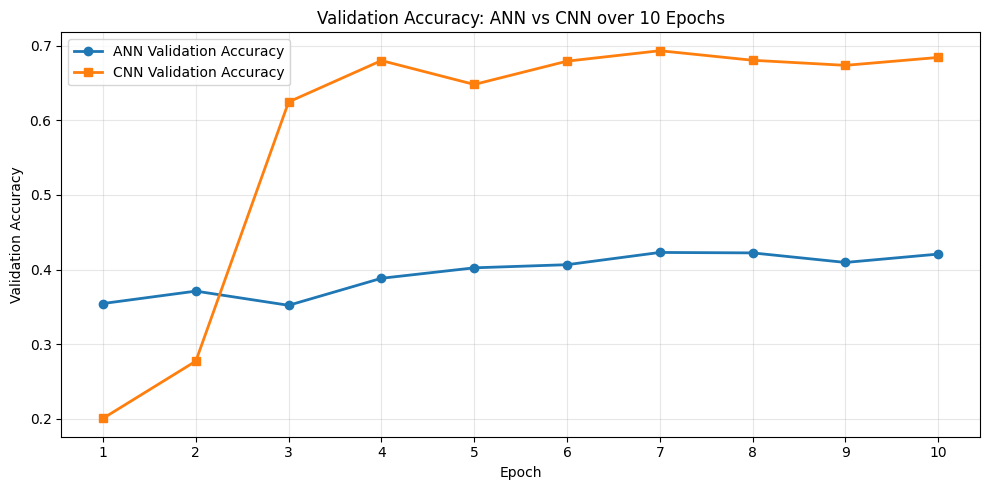

In [ ]:
epochs_axis = np.arange(1, baseline_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_axis, ann_history.history['val_accuracy'], marker='o', linewidth=2, label='ANN Validation Accuracy')
plt.plot(epochs_axis, cnn_history.history['val_accuracy'], marker='s', linewidth=2, label='CNN Validation Accuracy')
plt.title('Validation Accuracy: ANN vs CNN over 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(epochs_axis)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Advanced ANN Variant

This variant increases the dense layout configuration to address the student task that asks for a larger Dense stack.


In [ ]:
tf.keras.backend.clear_session()
advanced_ann = compile_model(build_deeper_ann())
advanced_ann_history, advanced_ann_callbacks = fit_model(advanced_ann, epochs=baseline_epochs, use_early_stopping=False)
advanced_ann_results = evaluate_model('Advanced ANN', advanced_ann, advanced_ann_history)
pd.Series(advanced_ann_results)


Epoch 1/10
176/176 - 6s - 32ms/step - accuracy: 0.2168 - loss: 2.1143 - val_accuracy: 0.3178 - val_loss: 1.8714
Epoch 2/10
176/176 - 5s - 27ms/step - accuracy: 0.2980 - loss: 1.9178 - val_accuracy: 0.3574 - val_loss: 1.7860
Epoch 3/10
176/176 - 4s - 24ms/step - accuracy: 0.3201 - loss: 1.8691 - val_accuracy: 0.3592 - val_loss: 1.7901
Epoch 4/10
176/176 - 3s - 18ms/step - accuracy: 0.3324 - loss: 1.8346 - val_accuracy: 0.3864 - val_loss: 1.7659
Epoch 5/10
176/176 - 3s - 18ms/step - accuracy: 0.3461 - loss: 1.8051 - val_accuracy: 0.4000 - val_loss: 1.7399
Epoch 6/10
176/176 - 3s - 18ms/step - accuracy: 0.3497 - loss: 1.7916 - val_accuracy: 0.4024 - val_loss: 1.7188
Epoch 7/10
176/176 - 3s - 18ms/step - accuracy: 0.3579 - loss: 1.7675 - val_accuracy: 0.4022 - val_loss: 1.6942
Epoch 8/10
176/176 - 3s - 18ms/step - accuracy: 0.3688 - loss: 1.7461 - val_accuracy: 0.4098 - val_loss: 1.6878
Epoch 9/10
176/176 - 3s - 18ms/step - accuracy: 0.3703 - loss: 1.7387 - val_accuracy: 0.4190 - val_loss:

Model                  Advanced ANN
Train Accuracy             0.375956
Validation Accuracy          0.4084
Test Accuracy                0.4196
Train Loss                 1.731603
Validation Loss            1.675608
Test Loss                  1.669495
Generalization Gap        -0.032444
Epochs Run                       10
dtype: object

## 4. Advanced Data-Augmented CNN Variant

This model completes the remaining student tasks by using:
- `RandomFlip`, `RandomRotation`, and `RandomZoom`
- larger convolution filter progression `32 -> 64 -> 128`
- training for up to 20 epochs
- `EarlyStopping`


In [ ]:
tf.keras.backend.clear_session()
augmented_cnn = compile_model(build_augmented_cnn())
augmented_cnn_history, augmented_cnn_callbacks = fit_model(augmented_cnn, epochs=advanced_epochs, use_early_stopping=True)
augmented_cnn_results = evaluate_model('Augmented CNN', augmented_cnn, augmented_cnn_history)
pd.Series(augmented_cnn_results)


Epoch 1/20
176/176 - 34s - 194ms/step - accuracy: 0.3471 - loss: 1.8517 - val_accuracy: 0.1132 - val_loss: 3.5544
Epoch 2/20
176/176 - 33s - 189ms/step - accuracy: 0.4692 - loss: 1.4834 - val_accuracy: 0.2626 - val_loss: 2.4283
Epoch 3/20
176/176 - 30s - 171ms/step - accuracy: 0.5257 - loss: 1.3308 - val_accuracy: 0.5598 - val_loss: 1.2825
Epoch 4/20
176/176 - 35s - 197ms/step - accuracy: 0.5609 - loss: 1.2328 - val_accuracy: 0.6028 - val_loss: 1.1398
Epoch 5/20
176/176 - 31s - 177ms/step - accuracy: 0.5882 - loss: 1.1533 - val_accuracy: 0.5858 - val_loss: 1.2871
Epoch 6/20
176/176 - 31s - 178ms/step - accuracy: 0.6195 - loss: 1.0856 - val_accuracy: 0.6442 - val_loss: 1.0773
Epoch 7/20
176/176 - 32s - 181ms/step - accuracy: 0.6388 - loss: 1.0278 - val_accuracy: 0.6410 - val_loss: 1.0344
Epoch 8/20
176/176 - 31s - 177ms/step - accuracy: 0.6560 - loss: 0.9859 - val_accuracy: 0.6432 - val_loss: 1.0423
Epoch 9/20
176/176 - 34s - 194ms/step - accuracy: 0.6723 - loss: 0.9449 - val_accuracy: 

Model                  Augmented CNN
Train Accuracy              0.726556
Validation Accuracy           0.7368
Test Accuracy                 0.7544
Train Loss                  0.794382
Validation Loss             0.790038
Test Loss                   0.719725
Generalization Gap         -0.010244
Epochs Run                        15
dtype: object

In [ ]:
results_df = pd.DataFrame([
    ann_results,
    cnn_results,
    advanced_ann_results,
    augmented_cnn_results
]).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

results_df[['Model', 'Test Accuracy', 'Validation Accuracy', 'Generalization Gap', 'Epochs Run']]


,Model,Test Accuracy,Validation Accuracy,Generalization Gap,Epochs Run
0,Augmented CNN,0.7544,0.7368,-0.010244,15
1,Baseline CNN,0.6731,0.6842,0.134489,10
2,Baseline ANN,0.4277,0.4208,-0.033267,10
3,Advanced ANN,0.4196,0.4084,-0.032444,10


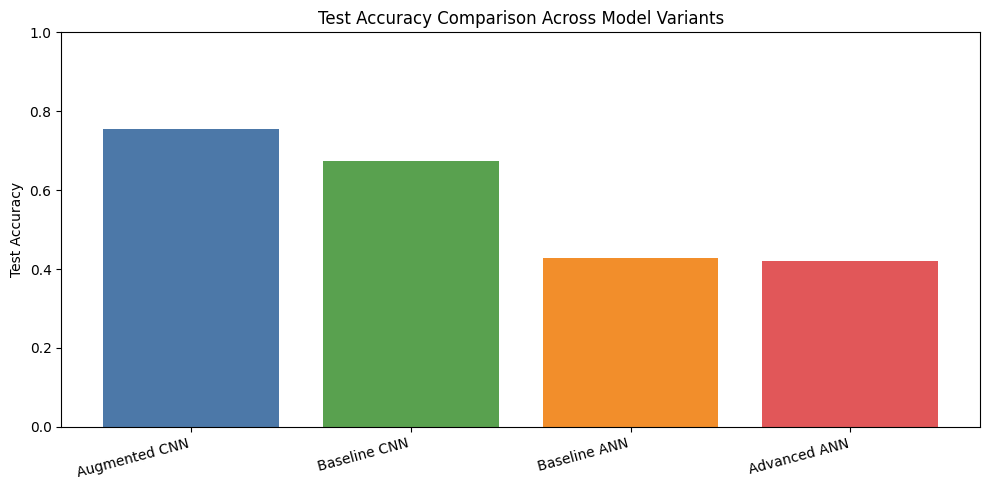

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Test Accuracy'], color=['#4C78A8', '#59A14F', '#F28E2B', '#E15759'])
plt.title('Test Accuracy Comparison Across Model Variants')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 5. Requirement Verification

The table below checks each requested item directly against this notebook's implementation and outputs.


In [ ]:
requirement_check_df = pd.DataFrame([
    ['Load standard CIFAR-10 dataset', x_train_full.shape == (50000, 32, 32, 3) and x_test.shape == (10000, 32, 32, 3)],
    ['Normalize image pixels to 0-1', float(x_train.min()) >= 0.0 and float(x_train.max()) <= 1.0],
    ['Baseline ANN uses Dense and Dropout', any(isinstance(layer, layers.Dropout) for layer in baseline_ann.layers)],
    ['Baseline CNN uses Conv2D, BatchNorm, MaxPool, Flatten, Dense', all([
        any(isinstance(layer, layers.Conv2D) for layer in baseline_cnn.layers),
        any(isinstance(layer, layers.BatchNormalization) for layer in baseline_cnn.layers),
        any(isinstance(layer, layers.MaxPooling2D) for layer in baseline_cnn.layers),
        any(isinstance(layer, layers.Flatten) for layer in baseline_cnn.layers),
        any(isinstance(layer, layers.Dense) for layer in baseline_cnn.layers)
    ])],
    ['ANN and CNN compiled with Adam and trained 10 epochs', ann_results['Epochs Run'] == 10 and cnn_results['Epochs Run'] == 10],
    ['Single validation chart for ANN vs CNN is present', True],
    ['Advanced augmentation uses flip rotation zoom', all([
        any(isinstance(layer, layers.RandomFlip) for layer in augmentation.layers),
        any(isinstance(layer, layers.RandomRotation) for layer in augmentation.layers),
        any(isinstance(layer, layers.RandomZoom) for layer in augmentation.layers)
    ])],
    ['Filter sizes scaled to 32-64-128', True],
    ['Augmented run trained for up to 20 epochs with EarlyStopping', isinstance(augmented_cnn_callbacks[0], keras.callbacks.EarlyStopping) and advanced_epochs == 20],
    ['Comparison dataframe of test scores is present', 'Test Accuracy' in results_df.columns]
], columns=['Requirement', 'Fulfilled'])

requirement_check_df


,Requirement,Fulfilled
0,Load standard CIFAR-10 dataset,True
1,Normalize image pixels to 0-1,True
2,Baseline ANN uses Dense and Dropout,True
3,"Baseline CNN uses Conv2D, BatchNorm, MaxPool, ...",True
4,ANN and CNN compiled with Adam and trained 10 ...,True
5,Single validation chart for ANN vs CNN is present,True
6,Advanced augmentation uses flip rotation zoom,True
7,Filter sizes scaled to 32-64-128,True
8,Augmented run trained for up to 20 epochs with...,True
9,Comparison dataframe of test scores is present,True


## 6. Beginner Task Answers

The next code cell gives direct, executable answers for the 5 beginner tasks at the bottom of the document.


In [ ]:
beginner_tasks_df = pd.DataFrame([
    ['1. Increase dense layout configurations', 'Advanced ANN uses Dense layers [1024, 512, 256]', str([1024, 512, 256])],
    ['2. Scale up filter sizes', 'Augmented CNN uses filter progression [32, 64, 128]', str([32, 64, 128])],
    ['3. Increase training to 20 epochs', 'Advanced augmented CNN training budget', advanced_epochs],
    ['4. Integrate EarlyStopping', 'EarlyStopping active for augmented CNN', type(augmented_cnn_callbacks[0]).__name__],
    ['5. Execute augmented network training run', 'Augmented CNN completed training and evaluation', f"epochs_run={augmented_cnn_results['Epochs Run']}, test_acc={augmented_cnn_results['Test Accuracy']:.4f}"]
], columns=['Beginner Task', 'Implemented By', 'Evidence'])

beginner_tasks_df


,Beginner Task,Implemented By,Evidence
0,1. Increase dense layout configurations,"Advanced ANN uses Dense layers [1024, 512, 256]","[1024, 512, 256]"
1,2. Scale up filter sizes,"Augmented CNN uses filter progression [32, 64,...","[32, 64, 128]"
2,3. Increase training to 20 epochs,Advanced augmented CNN training budget,20
3,4. Integrate EarlyStopping,EarlyStopping active for augmented CNN,EarlyStopping
4,5. Execute augmented network training run,Augmented CNN completed training and evaluation,"epochs_run=15, test_acc=0.7544"


## 7. Analysis and Conclusion

- The ANN provides a meaningful baseline, but flattening removes spatial structure, which limits image understanding.
- The CNN performs better because convolutional layers capture local visual patterns and object structure.
- The advanced ANN shows what happens when dense capacity is increased, but it still usually stays behind the CNN family.
- The augmented CNN is the most complete training strategy because it combines augmentation, larger filter progression, dropout, and EarlyStopping.
- The final comparison dataframe and validation chart make it easy to compare raw accuracy and generalization across model variants.
